In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data
from analysis import data_loading
from analysis import housemaze_analysis
from nicewebrl import dataframe

# env, example_timestep = housemaze_model_data.load_env_and_example_timestep()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


# Simulation data

In [4]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [5]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [6]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

searches = {
  "Paths": f"{data_dir}/user_data/*exps*/*v1*paths*.json",
  "Path-notell": f"{data_dir}/user_data/*exps*/*v2*r0*paths*.json",
  "Start": f"{data_dir}/user_data/*exps*/*v3*start*.json",
  #'Start-notell': f'{data_dir}/user_data/*exps*/*v2*r0*start*.json',
  "Plan (Tell)": f"{data_dir}/user_data/*exps*/*v2*r1-t0-plan*.json",
  "Plan (Don't Tell)": f"{data_dir}/user_data/*exps*/*v2*r0-t0-plan*.json",
  "Shortcut": f"{data_dir}/user_data/*exps*/*v3*shortcut*.json",
  # 'Shortcut-notell': f'{data_dir}/user_data/*exps*/*v2*r0*shortcut*.json',
}

valid_files = housemaze_user_data.get_valid_files(searches, verbose=True, plot=False)
user_df = housemaze_user_data.get_human_data(
  valid_files, overwrite_episode_data=False, overwrite_episode_info=False
)

Paths: 23/23 valid files
Path-notell: 24/24 valid files
Start: 25/25 valid files
Plan (Tell): 24/24 valid files
Plan (Don't Tell): 24/24 valid files
Shortcut: 24/24 valid files


/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid = os.fork()


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


Processing episodes:  90%|████████▉ | 35/39 [05:02<00:36,  9.21s/it]

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze

Processing episodes: 100%|██████████| 39/39 [05:46<00:00,  8.89s/it]


Combining results:   0%|          | 0/144 [00:00<?, ?it/s]

In [17]:
valid_files

['/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1156763655_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=2838747012_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=1537004505_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=3400741853_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=2946853427_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=4171123764_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=530036071_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//user_data/exps/user=705949786_name=exp5-v1-r1-t0-paths_debug=0.json',
 '/Users/wilka/git/research/results/human_dyna//us

# Analysis

In [6]:
# !pip install statsmodels

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


Power levels:   0%|          | 0/3 [00:00<?, ?it/s]

Simulating data:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

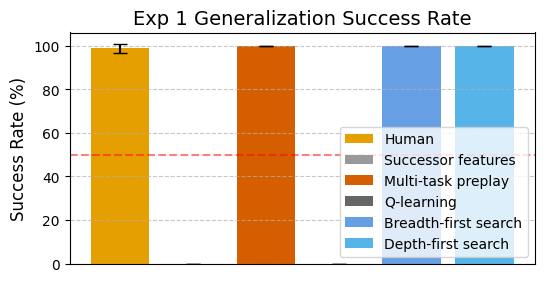

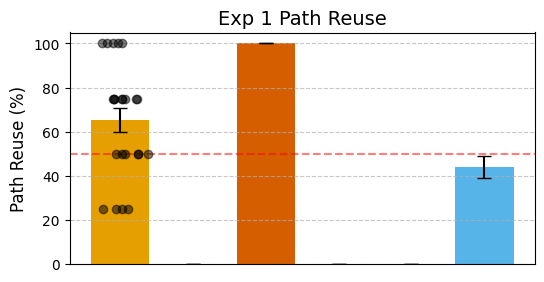

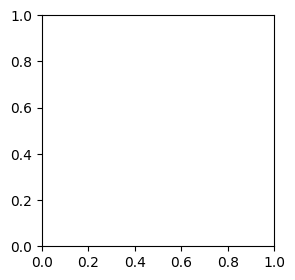

In [7]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/analysis_results/"
# %debug
housemaze_analysis.experiment_1_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  display_figs=False,
  save_figs=True,
  n_simulations=1000,
  verbosity=1,
)

In [57]:
# data_dir = '/Users/wilka/git/research/results/human_dyna/'
# save_dir = f'{data_dir}/analysis_results/'
# housemaze_analysis.experiment_1_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     display_figs=False,
#     save_figs=True)

Experiment 2 Statistical Analysis

Path Reuse Analysis

Analysis Results:
N = 24 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.833 (SE: 0.049)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 244.000
p = 0.000

Effect Size (r):
0.808

Required Sample Sizes:
Power 80%: N ≥ 3 participants
Power 90%: N ≥ 4 participants
Power 95%: N ≥ 4 participants



/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)


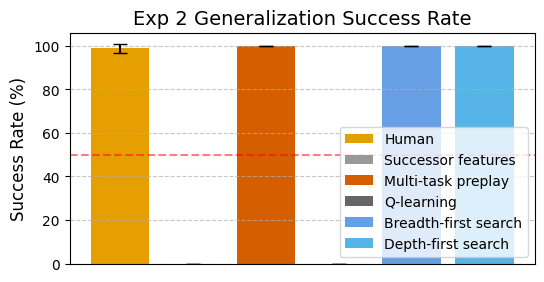

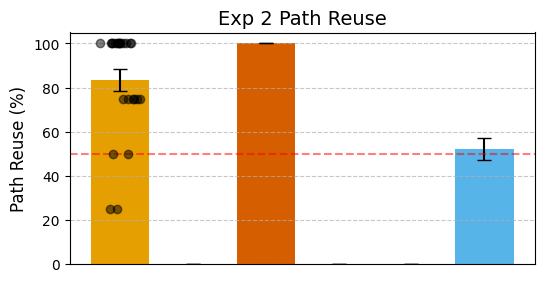

In [9]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/analysis_results/"


housemaze_analysis.experiment_2_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)
# housemaze_analysis.experiment_2_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     save_figs=True)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Experiment 3 Statistical Analysis


log_first_rt:
N = 25 participants
Mean difference = 0.276 (SE: 0.118)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 215.000
p = 0.082

Effect Size (r):
0.278

Power Analysis:
Achieved power with current N=25: 0.834
Required sample sizes:
  80% power: N ≥ 21
  90% power: N ≥ 29
  95% power: N ≥ 36

log_max_rt:
N = 25 participants
Mean difference = -0.085 (SE: 0.060)

Normality Test (Shapiro-Wilk):
p = 0.577 (Normal distribution)

Paired t-test:
statistic = -1.416
p = 0.915

Effect Size (Cohen's d):
-0.283

Power Analysis:
Achieved power with current N=25: 0.394
Required sample sizes:
  80% power: N ≥ 79
  90% power: N ≥ 109
  95% power: N ≥ 137

log_avg_rt:
N = 25 participants
Mean difference = -0.015 (SE: 0.023)

Normality Test (Shapiro-Wilk):
p = 0.636 (Normal dis

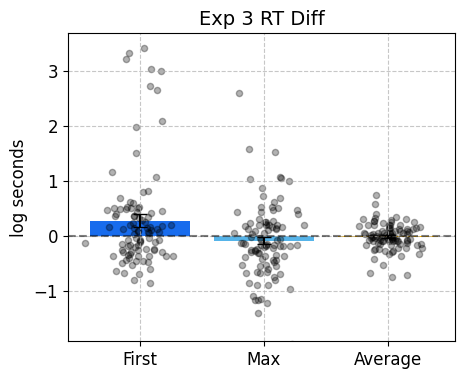

In [16]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/analysis_results/"
# %debug
housemaze_analysis.experiment_3_results(
  user_df,
  model_df,
  filter_columns=[],
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


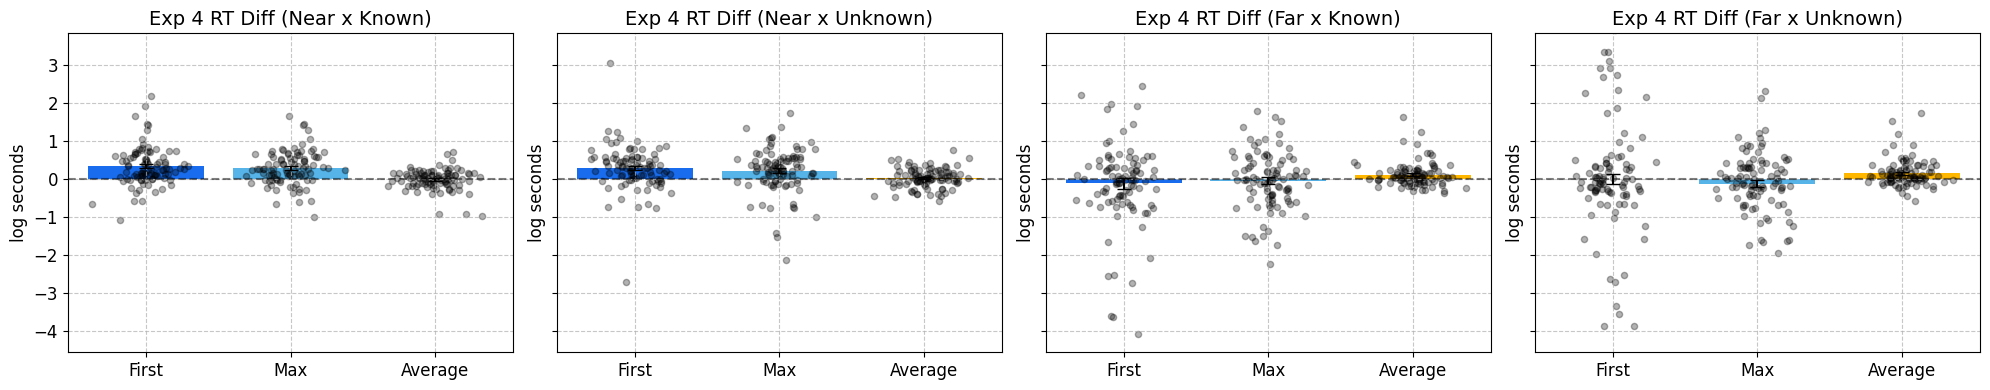

In [64]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/analysis_results/"
# %debug
housemaze_analysis.experiment_4_results(
  user_df,
  model_df,
  save_dir=save_dir,
  filter_columns=[],
  save_figs=True,
  display_figs=True,
)